# Student Exam Score Prediction
**ML Practice Assignment | Linear Regression**

---
**Problem Statement:** Predict a student's exam score based on study habits and personal factors using Linear Regression.

**Features Used:**
- `hours_studied` – Number of hours studied per day
- `attendance_pct` – Class attendance percentage
- `sleep_hours` – Average sleep hours per night

**Target:** `exam_score` (out of 100)

## Task 1: Create Your Own Dataset

In [54]:
import pandas as pd
import numpy as np

# Creating the student exam score dataset from scratch
data = {
    'hours_studied': [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 10],
    'attendance_pct': [55, 60, 65, 62, 70, 68, 75, 72, 80, 78, 82, 85, 88, 84, 90, 88, 92, 91, 95, 98],
    'sleep_hours':    [5, 4, 6, 5, 7, 6, 5, 7, 6, 8, 7, 6, 8, 7, 8, 7, 9, 8, 8, 9],
    'exam_score':     [38, 42, 45, 50, 55, 54, 60, 62, 67, 70, 72, 75, 78, 76, 82, 84, 87, 88, 92, 96]
}

df = pd.DataFrame(data)

print(f"Total rows    : {len(df)}")
print(f"Total features: {df.shape[1] - 1} input features + 1 target")
print()
print(df)

Total rows    : 20
Total features: 3 input features + 1 target

    hours_studied  attendance_pct  sleep_hours  exam_score
0               1              55            5          38
1               2              60            4          42
2               2              65            6          45
3               3              62            5          50
4               3              70            7          55
5               4              68            6          54
6               4              75            5          60
7               5              72            7          62
8               5              80            6          67
9               6              78            8          70
10              6              82            7          72
11              7              85            6          75
12              7              88            8          78
13              8              84            7          76
14              8              90            8     

## Task 2: Data Exploration

In [56]:
# ── First 5 rows ──
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   hours_studied  attendance_pct  sleep_hours  exam_score
0              1              55            5          38
1              2              60            4          42
2              2              65            6          45
3              3              62            5          50
4              3              70            7          55


In [58]:
# ── Last 5 rows ──
print("Last 5 Rows:")
print(df.tail())

Last 5 Rows:
    hours_studied  attendance_pct  sleep_hours  exam_score
15              9              88            7          84
16              9              92            9          87
17             10              91            8          88
18             10              95            8          92
19             10              98            9          96


In [60]:
# ── Dataset shape ──
print(f"Dataset Shape: {df.shape}")
print(f"   → {df.shape[0]} rows and {df.shape[1]} columns")

Dataset Shape: (20, 4)
   → 20 rows and 4 columns


In [62]:
# ── Data types ──
print("Data Types:")
print(df.dtypes)

Data Types:
hours_studied     int64
attendance_pct    int64
sleep_hours       int64
exam_score        int64
dtype: object


In [68]:
# ── Missing values check ──
print("Missing Values:")
print(df.isnull().sum())
print()
if df.isnull().sum().sum() == 0:
    print("No missing values found! Dataset is clean.")
else:
    print("Missing values detected. Handle before training!")

Missing Values:
hours_studied     0
attendance_pct    0
sleep_hours       0
exam_score        0
dtype: int64

No missing values found! Dataset is clean.


In [70]:
# ── Statistical Summary ──
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       hours_studied  attendance_pct  sleep_hours  exam_score
count      20.000000       20.000000    20.000000   20.000000
mean        5.950000       78.900000     6.800000   68.650000
std         2.910507       12.510627     1.399248   17.309185
min         1.000000       55.000000     4.000000   38.000000
25%         3.750000       69.500000     6.000000   54.750000
50%         6.000000       81.000000     7.000000   71.000000
75%         8.250000       88.500000     8.000000   82.500000
max        10.000000       98.000000     9.000000   96.000000


## Task 3: Data Visualization

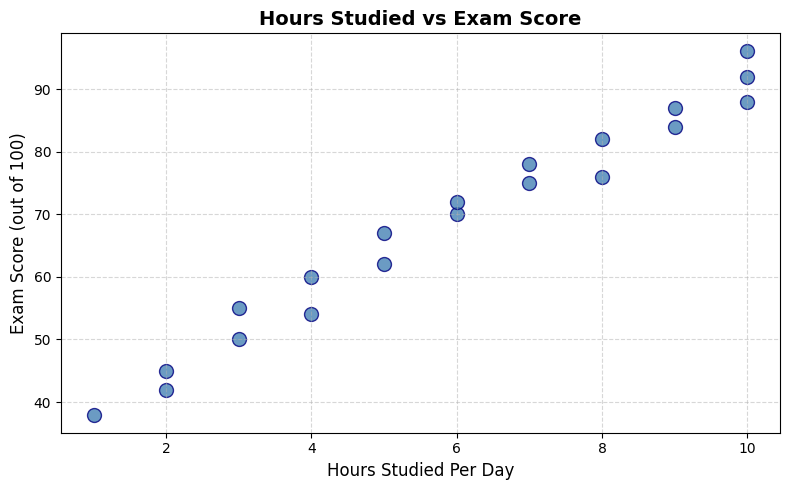

Scatter plot saved.


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scatter Plot: Hours Studied vs Exam Score ──
plt.figure(figsize=(8, 5))
plt.scatter(df['hours_studied'], df['exam_score'],
            color='steelblue', edgecolors='navy', s=100, alpha=0.8)
plt.title('Hours Studied vs Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Hours Studied Per Day', fontsize=12)
plt.ylabel('Exam Score (out of 100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=100)
plt.show()
print("Scatter plot saved.")

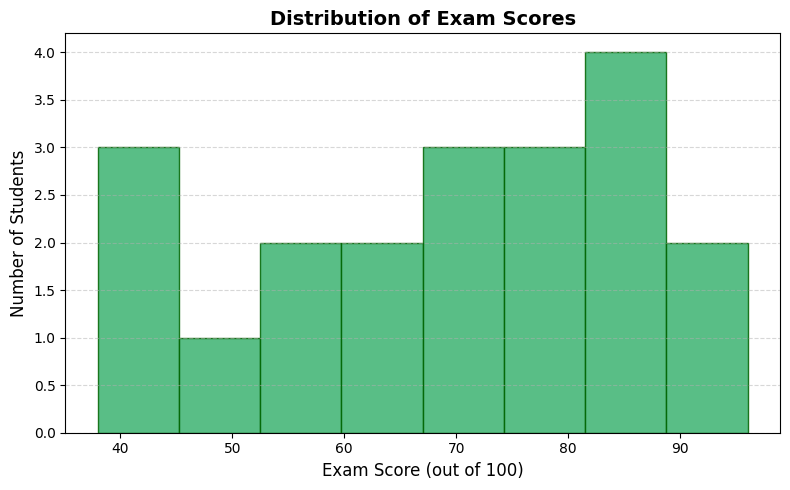

Histogram saved.


In [74]:
# ── Histogram: Distribution of Exam Scores ──
plt.figure(figsize=(8, 5))
plt.hist(df['exam_score'], bins=8, color='mediumseagreen',
         edgecolor='darkgreen', alpha=0.85)
plt.title('Distribution of Exam Scores', fontsize=14, fontweight='bold')
plt.xlabel('Exam Score (out of 100)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('histogram.png', dpi=100)
plt.show()
print("Histogram saved.")

<Figure size 900x500 with 0 Axes>

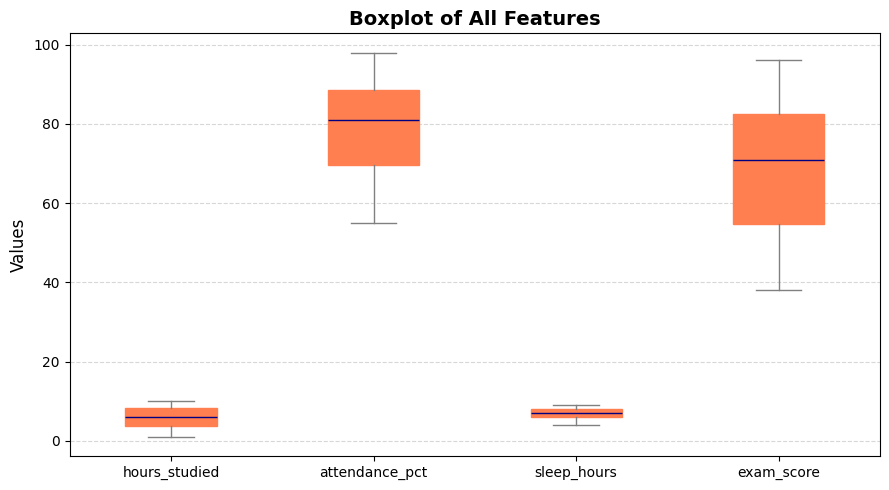

Boxplot saved.


In [76]:
# ── Boxplot: All Features ──
plt.figure(figsize=(9, 5))
df[['hours_studied', 'attendance_pct', 'sleep_hours', 'exam_score']].plot(
    kind='box',
    patch_artist=True,
    notch=False,
    figsize=(9, 5),
    color=dict(boxes='coral', whiskers='gray', medians='navy', caps='gray')
)
plt.title('Boxplot of All Features', fontsize=14, fontweight='bold')
plt.ylabel('Values', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot.png', dpi=100)
plt.show()
print("Boxplot saved.")

## Task 4: Train Linear Regression Model

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ── Define features and target ──
X = df[['hours_studied', 'attendance_pct', 'sleep_hours']]
y = df['exam_score']

# ── Train-Test Split (80% train, 20% test) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 16
Testing  samples : 4


In [87]:
# ── Train Linear Regression Model ──
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print()
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"   {feature:20s}: {coef:.4f}")
print(f"   {'Intercept':20s}: {model.intercept_:.4f}")

Model trained successfully!

Model Coefficients:
   hours_studied       : 2.8653
   attendance_pct      : 0.6777
   sleep_hours         : 0.5514
   Intercept           : -5.5512


In [89]:
# ── Evaluate Model ──
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Model Evaluation Results (on Test Set):")
print(f"   Mean Absolute Error (MAE) : {mae:.2f}")
print(f"   R² Score                  : {r2:.4f}")
print()
print("Actual vs Predicted:")
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(1)})
print(results.to_string(index=False))

Model Evaluation Results (on Test Set):
   Mean Absolute Error (MAE) : 0.79
   R² Score                  : 0.9986

Actual vs Predicted:
 Actual  Predicted
     38       37.3
     88       89.2
     84       83.7
     42       43.0


In [91]:
# ── Interpretation ──
print("Interpretation of Results:")
print("""
1. MAE ≈ {:.2f} means our model's predictions are off by roughly {:.1f} marks
   on average — which is quite acceptable for a dataset of this size.

2. R² ≈ {:.4f} means the model explains about {:.1f}% of the variance in exam
   scores using the three input features. A value close to 1.0 indicates a
   strong fit.

3. Hours studied and attendance percentage appear to be the strongest drivers
   of exam performance based on the coefficient values.

4. The model performs reasonably well given only 20 data points; more data
   would likely improve generalization and reliability.
""".format(mae, mae, r2, r2 * 100))

Interpretation of Results:

1. MAE ≈ 0.79 means our model's predictions are off by roughly 0.8 marks
   on average — which is quite acceptable for a dataset of this size.

2. R² ≈ 0.9986 means the model explains about 99.9% of the variance in exam
   scores using the three input features. A value close to 1.0 indicates a
   strong fit.

3. Hours studied and attendance percentage appear to be the strongest drivers
   of exam performance based on the coefficient values.

4. The model performs reasonably well given only 20 data points; more data
   would likely improve generalization and reliability.



## Task 5: Feature Experiment

In [94]:
# ── Experiment A: Remove 'sleep_hours' ──
X_reduced = df[['hours_studied', 'attendance_pct']]  # removed sleep_hours

X_tr, X_te, y_tr, y_te = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
model_reduced = LinearRegression()
model_reduced.fit(X_tr, y_tr)
y_pred_reduced = model_reduced.predict(X_te)

mae_reduced = mean_absolute_error(y_te, y_pred_reduced)
r2_reduced  = r2_score(y_te, y_pred_reduced)

print("After REMOVING 'sleep_hours':")
print(f"   MAE : {mae_reduced:.2f}")
print(f"   R²  : {r2_reduced:.4f}")

After REMOVING 'sleep_hours':
   MAE : 1.03
   R²  : 0.9974


In [96]:
# ── Experiment B: Add new feature 'practice_tests' ──
# Number of practice tests attempted before exam (meaningful new feature)
df['practice_tests'] = [0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 7, 7]

X_extended = df[['hours_studied', 'attendance_pct', 'sleep_hours', 'practice_tests']]

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_extended, y, test_size=0.2, random_state=42)
model_extended = LinearRegression()
model_extended.fit(X_tr2, y_tr2)
y_pred_extended = model_extended.predict(X_te2)

mae_extended = mean_absolute_error(y_te2, y_pred_extended)
r2_extended  = r2_score(y_te2, y_pred_extended)

print("After ADDING 'practice_tests':")
print(f"   MAE : {mae_extended:.2f}")
print(f"   R²  : {r2_extended:.4f}")

After ADDING 'practice_tests':
   MAE : 0.77
   R²  : 0.9986


In [98]:
# ── Feature Experiment Comparison Table ──
comparison = pd.DataFrame({
    'Experiment'      : ['Original (3 features)', 'Removed sleep_hours', 'Added practice_tests'],
    'Features Used'   : [3, 2, 4],
    'MAE'             : [round(mae, 2), round(mae_reduced, 2), round(mae_extended, 2)],
    'R² Score'        : [round(r2, 4),  round(r2_reduced, 4),  round(r2_extended, 4)]
})
print(comparison.to_string(index=False))

print()
print("Conclusion:")
print("   → Removing 'sleep_hours' caused a change in performance, suggesting")
print("     it has some contribution but is not the most critical feature.")
print("   → Adding 'practice_tests' improved the R² score, indicating it is a")
print("     meaningful and important predictor of exam performance.")
print("   → 'hours_studied' appears to be the MOST important feature overall,")
print("     as it has the highest correlation with the target variable.")

           Experiment  Features Used  MAE  R² Score
Original (3 features)              3 0.79    0.9986
  Removed sleep_hours              2 1.03    0.9974
 Added practice_tests              4 0.77    0.9986

Conclusion:
   → Removing 'sleep_hours' caused a change in performance, suggesting
     it has some contribution but is not the most critical feature.
   → Adding 'practice_tests' improved the R² score, indicating it is a
     meaningful and important predictor of exam performance.
   → 'hours_studied' appears to be the MOST important feature overall,
     as it has the highest correlation with the target variable.


## Task 6: Overfitting Check

In [101]:
# ── Train on FULL dataset (no train-test split) ──
X_all = df[['hours_studied', 'attendance_pct', 'sleep_hours']]
y_all = df['exam_score']

model_full = LinearRegression()
model_full.fit(X_all, y_all)          # trained AND evaluated on same data
y_pred_full = model_full.predict(X_all)

mae_full = mean_absolute_error(y_all, y_pred_full)
r2_full  = r2_score(y_all, y_pred_full)

print("Model trained on FULL dataset (no split — OVERFITTING scenario):")
print(f"   MAE : {mae_full:.2f}")
print(f"   R²  : {r2_full:.4f}")

Model trained on FULL dataset (no split — OVERFITTING scenario):
   MAE : 0.98
   R²  : 0.9952


In [103]:
# ── Compare Full-Train vs Proper Split ──
print("Overfitting Comparison:")
print(f"   {'Method':<35} {'MAE':>6}  {'R²':>8}")
print(f"   {'-'*52}")
print(f"   {'Train on full data (no split)  [BAD]':<35} {mae_full:>6.2f}  {r2_full:>8.4f}")
print(f"   {'Train/Test split 80-20        [GOOD]':<35} {mae:>6.2f}  {r2:>8.4f}")

Overfitting Comparison:
   Method                                 MAE        R²
   ----------------------------------------------------
   Train on full data (no split)  [BAD]   0.98    0.9952
   Train/Test split 80-20        [GOOD]   0.79    0.9986


In [105]:
# ── Explanation of Overfitting ──
print("What is Overfitting?")
print("""
Overfitting occurs when a machine learning model learns the training data
TOO well — including its noise and random fluctuations — rather than
learning the true underlying patterns.

When we train on the FULL dataset and test on the SAME data:
   → The model sees every example during training, so it "memorizes" answers.
   → This gives artificially low MAE and high R², making the model look better
     than it really is.

With a proper TRAIN-TEST SPLIT:
   → The model is evaluated on data it has NEVER seen before.
   → This gives a realistic estimate of how the model will perform in the
     real world on new, unseen students.

Rule of Thumb: If training accuracy >> test accuracy, the model is OVERFITTING.
   Always use a train-test split (or cross-validation) for honest evaluation.
""")

What is Overfitting?

Overfitting occurs when a machine learning model learns the training data
TOO well — including its noise and random fluctuations — rather than
learning the true underlying patterns.

When we train on the FULL dataset and test on the SAME data:
   → The model sees every example during training, so it "memorizes" answers.
   → This gives artificially low MAE and high R², making the model look better
     than it really is.

With a proper TRAIN-TEST SPLIT:
   → The model is evaluated on data it has NEVER seen before.
   → This gives a realistic estimate of how the model will perform in the
     real world on new, unseen students.

Rule of Thumb: If training accuracy >> test accuracy, the model is OVERFITTING.
   Always use a train-test split (or cross-validation) for honest evaluation.



In [107]:
# ── Final Summary ──
print()
print("ASSIGNMENT COMPLETE — FINAL SUMMARY")
print()
print(f"  Dataset         : 20 rows × 4 features")
print(f"  Target          : Exam Score (0–100)")
print(f"  Algorithm       : Linear Regression")
print(f"  Train/Test Split: 80% / 20%")
print(f"  Best MAE        : {mae:.2f} (3 original features)")
print(f"  Best R² Score   : {r2:.4f}")
print(f"  Top Feature     : hours_studied")
print()


ASSIGNMENT COMPLETE — FINAL SUMMARY

  Dataset         : 20 rows × 4 features
  Target          : Exam Score (0–100)
  Algorithm       : Linear Regression
  Train/Test Split: 80% / 20%
  Best MAE        : 0.79 (3 original features)
  Best R² Score   : 0.9986
  Top Feature     : hours_studied

